In [3]:
import pandas as pd
from bs4 import BeautifulSoup
import re
from pathlib import Path

BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data"

# Ensure data folder exists
DATA_DIR.mkdir(exist_ok=True)

# File paths
input_path  = DATA_DIR / "Resume.csv"
output_path = DATA_DIR / "cleaned_resumes.csv"

print("Reading from:", input_path.resolve())
print("File exists:", input_path.exists())

# -------------------------------
# 2. Load data
# -------------------------------
df = pd.read_csv(input_path)

print(df.shape)
print(df.columns)
print(df['Category'].value_counts())

# -------------------------------
# 3. Keep required columns
# -------------------------------
df = df[['ID', 'Resume_str', 'Category']]

print(df.isnull().sum())
print(df.duplicated().sum())

# Remove bad rows
df = df.dropna(subset=['Resume_str'])
df = df[df['Resume_str'].str.strip() != '']

# -------------------------------
# 4. Cleaning function
# -------------------------------
def clean_text(text):
    text = str(text)
    text = BeautifulSoup(text, 'html.parser').get_text()
    text = re.sub(r'[^a-zA-Z0-9\s\+\#\.]', ' ', text)
    text = text.lower().strip()
    text = re.sub(r'\s+', ' ', text)
    return text

df['cleaned_resume'] = df['Resume_str'].apply(clean_text)

# Remove empty cleaned text
df = df[df['cleaned_resume'].str.strip() != '']

# -------------------------------
# 5. Target creation
# -------------------------------
df['target'] = (df['Category'] == 'INFORMATION-TECHNOLOGY').astype(int)

print(df['target'].value_counts())
print("Final shape:", df.shape)

# -------------------------------
# 6. Save cleaned dataset
# -------------------------------
df.to_csv(output_path, index=False)

print("Saved to:", output_path.resolve())

Reading from: C:\Users\Lokesh\OneDrive\Desktop\AMRITA\HireIQ\data\Resume.csv
File exists: True
(2484, 4)
Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64
ID            0
Resume_str    0
Category      0
dtype: int64
0
target

In [4]:
from pathlib import Path
import re

BASE_DIR = Path.cwd().parent  
DATA_PATH = BASE_DIR / "data" / "cleaned_resumes.csv"
TECH_SKILLS = [
    'python','java','sql','javascript','aws','docker','linux',
    'git','machine learning','deep learning','tensorflow','pytorch',
    'pandas','numpy','spark','hadoop','kubernetes','react','node',
    'mongodb','postgresql','redis','api','rest','agile','ci/cd',
    'tableau','power bi','excel','r programming'
]

# -------------------------------
# Feature functions (optimized)
# -------------------------------
def extract_years(text):
    text = str(text).lower()
    matches = re.findall(r'(\d+)\s*year', text)
    return max(map(int, matches)) if matches else 0

def has_degree(text):
    text = str(text).lower()
    keywords = ['bachelor','master','phd','mba','b.tech','m.tech']
    return int(any(k in text for k in keywords))

def skill_count(text):
    text = str(text).lower()
    return sum(skill in text for skill in TECH_SKILLS)

df['years_experience'] = df['cleaned_resume'].apply(extract_years)
df['has_degree']       = df['cleaned_resume'].apply(has_degree)
df['skill_keywords']   = df['cleaned_resume'].apply(skill_count)

df.to_csv(DATA_PATH, index=False)

print("Saved to:", DATA_PATH.resolve())

Saved to: C:\Users\Lokesh\OneDrive\Desktop\AMRITA\HireIQ\data\cleaned_resumes.csv


In [6]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
import joblib
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

BASE_DIR = Path.cwd().parent  
DATA_PATH = BASE_DIR / "data" / "cleaned_resumes.csv"
MODEL_DIR = BASE_DIR / "models"


MODEL_DIR.mkdir(exist_ok=True)
df = pd.read_csv(DATA_PATH)

# Safety: remove any bad rows
df = df.dropna(subset=['cleaned_resume'])

X_text = df['cleaned_resume']
X_extra = df[['years_experience', 'has_degree', 'skill_keywords']].values
y = df['target'].values

# -------------------------------
# 3. TF-IDF Vectorization
# -------------------------------
tfidf = TfidfVectorizer(max_features=500,stop_words='english',ngram_range=(1, 2),min_df=2,max_df=0.9)
X_tfidf = tfidf.fit_transform(X_text)

# Combine TF-IDF + engineered features
X = sp.hstack([X_tfidf, sp.csr_matrix(X_extra)])

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

# 5. Handle Class Imbalance
neg, pos = np.bincount(y_train)
scale_pw = neg / pos if pos != 0 else 1

model = XGBClassifier(n_estimators=300,max_depth=6,learning_rate=0.05,subsample=0.8,
    colsample_bytree=0.8,scale_pos_weight=scale_pw,eval_metric='logloss',random_state=42,n_jobs=-1)

model.fit(X_train, y_train)

joblib.dump(model, MODEL_DIR / "model.pkl")
joblib.dump(tfidf, MODEL_DIR / "vectorizer.pkl")
joblib.dump(tfidf.get_feature_names_out(),MODEL_DIR / "feature_names.pkl")

print("Training complete.")
print("Saved model to:", (MODEL_DIR / "model.pkl").resolve())
print("Saved vectorizer to:", (MODEL_DIR / "vectorizer.pkl").resolve())
print("Saved feature names to:", (MODEL_DIR / "feature_names.pkl").resolve())

Training complete.
Saved model to: C:\Users\Lokesh\OneDrive\Desktop\AMRITA\HireIQ\models\model.pkl
Saved vectorizer to: C:\Users\Lokesh\OneDrive\Desktop\AMRITA\HireIQ\models\vectorizer.pkl
Saved feature names to: C:\Users\Lokesh\OneDrive\Desktop\AMRITA\HireIQ\models\feature_names.pkl


              precision    recall  f1-score   support

       Other       0.99      0.99      0.99       473
          IT       0.73      0.79      0.76        24

    accuracy                           0.98       497
   macro avg       0.86      0.89      0.87       497
weighted avg       0.98      0.98      0.98       497

ROC-AUC: 0.970
[[466   7]
 [  5  19]]
Best threshold: 0.441  F1 at best: 0.792
F1 with tuned threshold: 0.792


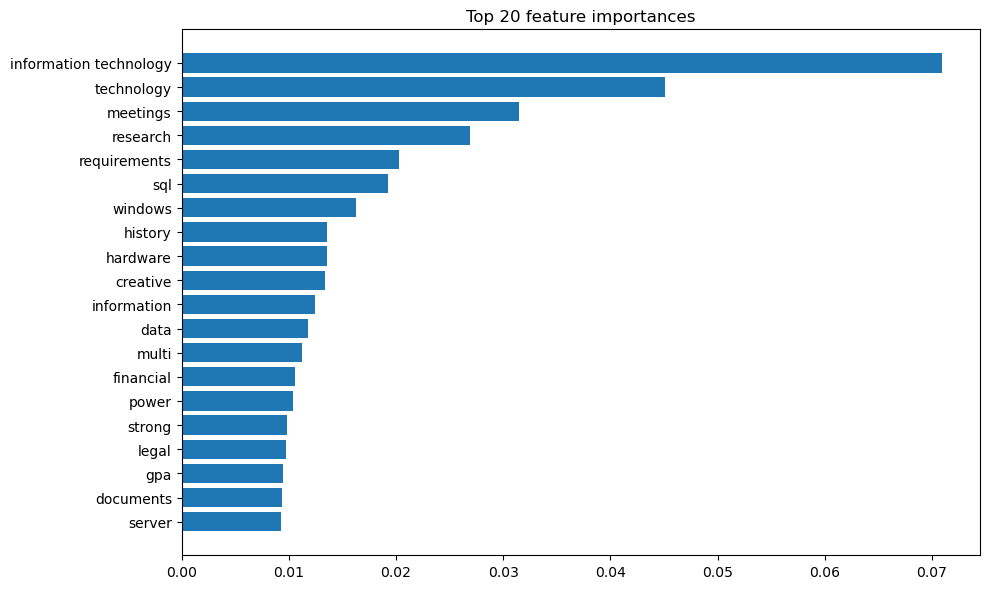

In [7]:
from sklearn.metrics import (classification_report, confusion_matrix,roc_auc_score, 
    precision_recall_curve, f1_score)
import matplotlib.pyplot as plt

y_pred      = model.predict(X_test)
y_proba     = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Other','IT']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")
print(confusion_matrix(y_test, y_pred))

# --- Threshold tuning ---
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
best_thresh = thresholds[np.argmax(f1_scores)]
print(f"Best threshold: {best_thresh:.3f}  F1 at best: {f1_scores.max():.3f}")

# Apply custom threshold
y_pred_tuned = (y_proba >= best_thresh).astype(int)
print(f"F1 with tuned threshold: {f1_score(y_test, y_pred_tuned):.3f}")

# --- Feature importance ---
feature_names = tfidf.get_feature_names_out().tolist() + \
                ['years_experience','has_degree','skill_keywords']
importances   = model.feature_importances_
top_idx       = np.argsort(importances)[-20:]

plt.figure(figsize=(10, 6))
plt.barh([feature_names[i] for i in top_idx], importances[top_idx])
plt.title('Top 20 feature importances')
plt.tight_layout()
plt.savefig('feature_importance.png')